In [31]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import re
from glob import glob
from PIL import Image
import torchvision.transforms as T
import cv2
import dlib
import torch
# from imutils.face_utils import FaceAligner
import imutils
from tqdm.notebook import tqdm # Utilise tqdm.notebook pour un affichage adapté
from collections import Counter
import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))


In [2]:
# # Télécharger le modèle de landmarks de dlib
# if not os.path.exists("shape_predictor_68_face_landmarks.dat"):
#     # Commande pour télécharger le fichier de modèle
#     !wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
#     !bzip2 -d shape_predictor_68_face_landmarks.dat.bz2

# # Initialisation des détecteurs
# detector = dlib.get_frontal_face_detector()
# predictor = dlib.shape_predictor('shape_predictor_68_face_landmarks.dat')

--2025-09-24 20:23:07--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2025-09-24 20:23:07--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  40.0MB/s    in 1.5s    

2025-09-24 20:23:09 (40.0 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



In [3]:
# def detect_and_align_face(image, detector, predictor, target_size=224):
#     """
#     Détecte et aligne le premier visage trouvé dans une image.
#     Retourne un PIL.Image (recadrée et alignée) ou l'image originale si aucun visage.
#     """
#     img_np = np.array(image)
#     faces = detector(img_np, 1)  # upscale=1
#     if len(faces) > 0:
#         face = faces[0]
#         landmarks = predictor(img_np, face)
#         aligned_face = dlib.get_face_chip(img_np, landmarks, size=target_size)
#         return Image.fromarray(aligned_face)
#     else:
#         print("⚠️ Aucun visage détecté, image originale utilisée.")
#         return image


In [11]:
# Définition des chemins d'entrée et de sortie
# Les datasets Kaggle sont montés ici
INPUT_DIR = '/kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_2/dataset_tache_2'
TRAIN_DIR = os.path.join(INPUT_DIR, 'train')
TEST_DIR = os.path.join(INPUT_DIR, 'test')
# Seul le répertoire /kaggle/working/ est inscriptible
OUTPUT_DIR = '/kaggle/working'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Task 2: Age Estimation

## Prétraitement de données

Intervalle d'âge : 16 à 77 ans
Nombre d'images : 40012


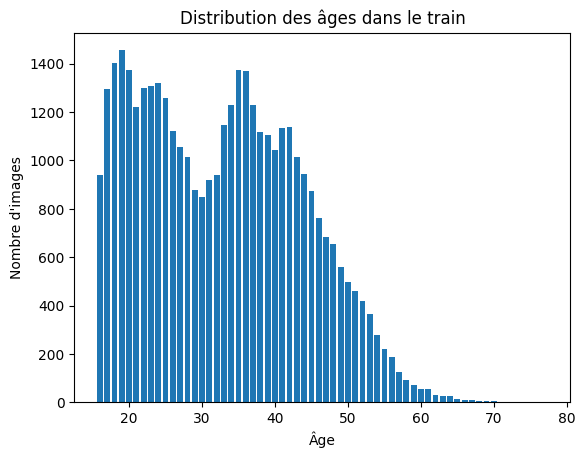

In [33]:
# Parser les âges
ages = []
for filename in os.listdir(TRAIN_DIR):
    if filename.endswith('.JPG') or filename.endswith('.jpg'):
        # parts = filename.split('_')
        # if len(parts) == 2:
        #     label = parts[1].split('.')[0]  # Ex. '01M16' -> âge est les 2 derniers chars
        #     age_str = label[-2:]  # WW
        #     try:
        #         age = int(age_str)
        #         ages.append(age)
        #     except ValueError:
        #         print(f"Erreur parsing {filename}")
        match = re.search(r'[MF](\d+)', filename)
        age = int(match.group(1)) if match else -1
        ages.append(age)


# Stats
if ages:
    min_age = min(ages)
    max_age = max(ages)
    print(f"Intervalle d'âge : {min_age} à {max_age} ans")
    print(f"Nombre d'images : {len(ages)}")

    # Histogramme pour distribution
    age_counts = Counter(ages)
    plt.bar(age_counts.keys(), age_counts.values())
    plt.xlabel('Âge')
    plt.ylabel('Nombre d\'images')
    plt.title('Distribution des âges dans le train')
    plt.show()
else:
    print("Aucun fichier valide trouvé.")

##  Preprocessing

In [35]:
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, Subset

class AgeDataset(Dataset):
    def __init__(self, dir_path=TRAIN_DIR, transform=None, target_size=224):
        self.dir_path = dir_path
        self.transform = transform
        self.images = [f for f in os.listdir(dir_path) if f.endswith('.jpg') or f.endswith('.JPG')]
        self.detector = detector
        self.predictor = predictor
        self.target_size = target_size
    
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.dir_path, self.images[idx])
        image = Image.open(img_path).convert('RGB')
        # cropped_image = detect_and_align_face(image, self.detector, self.predictor, self.target_size)
        # Parse âge
        match = re.search(r'[MF](\d+)', self.images[idx])
        age = int(match.group(1)) if match else -1

        if self.transform:
            image = self.transform(image)
        return image, age  # Âge comme int/float pour régression

# Transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Loaders
train_dataset = AgeDataset(TRAIN_DIR, train_transform)

# Indices de tout le dataset
indices = list(range(len(train_dataset)))

# Split 70/30
ages = [int(re.search(r'[MF](\d+)', f).group(1)) for f in train_dataset.images]
# Créer des bins (par ex. 16-20, 21-25, …)
age_bins = np.digitize(ages, bins=range(16, 78, 5))

train_idx, val_idx = train_test_split(
    indices, test_size=0.3, stratify=age_bins, random_state=42
) # avec stratification par âge

# Sous-ensembles
train_subset = Subset(train_dataset, train_idx)
val_subset   = Subset(train_dataset, val_idx)

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=32, shuffle=False)

## Aperçu des images après prétraitement

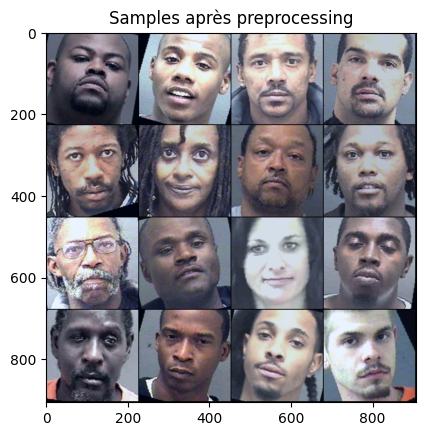

In [36]:
import torchvision.utils as vutils

# Prends un batch
images, labels = next(iter(train_loader))

# Grid
grid = vutils.make_grid(images[:16], nrow=4, normalize=True)  # Denormalize pour affichage
plt.imshow(grid.permute(1, 2, 0))
plt.title('Samples après preprocessing')
plt.show()

## Modèle : Architecture ResNet avec sortie Linear

In [50]:
import torch.nn as nn
from torchvision.models import resnet18

model = resnet18(pretrained=True)  # From 
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)  # Sortie : 1 pour âge (régression)

# Loss et optimizer
criterion = nn.L1Loss()  # Pour MAE (mieux que MSE pour âges)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [51]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=5):
    model = model.to(device)
    best_mae = float('inf')
    counter = 0
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Phase d'entraînement
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.float().to(device).unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss = train_loss / len(train_loader)
        train_losses.append(train_loss)

        # Phase de validation
        model.eval()
        val_loss = 0
        mae = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.float().to(device).unsqueeze(1)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
            val_loss = val_loss / len(val_loader)
            val_losses.append(val_loss)

        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        # Early stopping
        if val_loss < best_mae:
            best_mae = val_loss
            counter = 0
            torch.save(model.state_dict(), 'best_model_task2_regression.pth')
        else:
            counter += 1
            if counter >= patience:
                print(f'Early stopping triggered after epoch {epoch+1}')
                break

    # Retourner les pertes pour plotting
    return train_losses, val_losses

In [52]:
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=20, device=device)

Epoch[1/20], Train Loss: 5.3998, Val Loss: 5.1187
Epoch[2/20], Train Loss: 4.0950, Val Loss: 3.7022
Epoch[3/20], Train Loss: 3.8254, Val Loss: 3.6516
Epoch[4/20], Train Loss: 3.6693, Val Loss: 3.3610
Epoch[5/20], Train Loss: 3.5666, Val Loss: 3.4180
Epoch[6/20], Train Loss: 3.4257, Val Loss: 3.2794
Epoch[7/20], Train Loss: 3.3747, Val Loss: 3.3976
Epoch[8/20], Train Loss: 3.3074, Val Loss: 3.5254
Epoch[9/20], Train Loss: 3.2135, Val Loss: 3.1605
Epoch[10/20], Train Loss: 3.1325, Val Loss: 3.3301
Epoch[11/20], Train Loss: 3.0643, Val Loss: 3.0622
Epoch[12/20], Train Loss: 2.9488, Val Loss: 3.0498
Epoch[13/20], Train Loss: 2.9250, Val Loss: 3.1217
Epoch[14/20], Train Loss: 2.8777, Val Loss: 3.2309
Epoch[15/20], Train Loss: 2.8123, Val Loss: 2.9899
Epoch[16/20], Train Loss: 2.7871, Val Loss: 3.0219
Epoch[17/20], Train Loss: 2.7389, Val Loss: 3.0212
Epoch[18/20], Train Loss: 2.7150, Val Loss: 3.0144
Epoch[19/20], Train Loss: 2.6648, Val Loss: 3.0345
Epoch[20/20], Train Loss: 2.6417, Val Lo

In [ ]:
# Charger le meilleur modèle après entraînement
# model.load_state_dict(torch.load('best_model_task2_regression.pth'))
# model.eval()

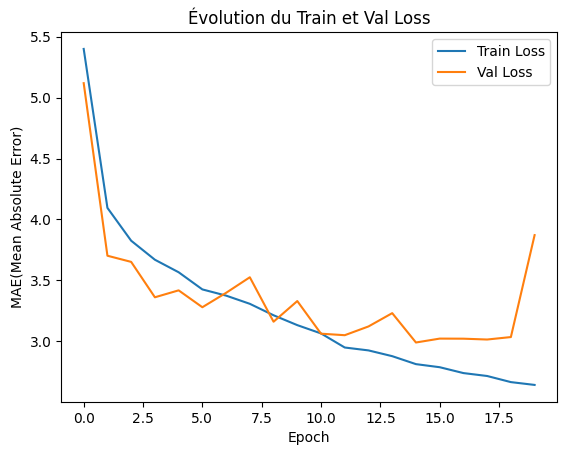

In [53]:
plt.plot(range(len(train_losses)), train_losses, label='Train Loss')
plt.plot(range(len(val_losses)), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE(Mean Absolute Error)')
plt.title('Évolution du Train et Val Loss')
plt.legend()
plt.show()

## Ensemble de Test et Prédictions

In [54]:
class AgeDatasetTest(Dataset):
    def __init__(self, dir_path, transform=None, target_size=224):
        self.dir_path = dir_path
        self.transform = transform
        self.images = [f for f in os.listdir(dir_path) if f.endswith('.jpg') or f.endswith('.JPG')]
        self.detector = detector
        self.predictor = predictor
        self.target_size = target_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.dir_path, self.images[idx])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        # Pas de label pour test, retourne juste l'image et l'ID
        image_id = int(os.path.splitext(self.images[idx])[0])  # Extrait l'ID (0, 10, etc.)
        return image, image_id

# Charger le test set
test_transform = transforms.Compose([  # Sans augmentations
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = AgeDatasetTest(TEST_DIR, test_transform, target_size=224)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [55]:
# Charger le meilleur modèle
model.load_state_dict(torch.load('best_model_task2_regression.pth'))
model.eval()
model = model.to(device)

# Prédire sur le test set
predictions = []
image_ids = []

with torch.no_grad():
    for images, ids in test_loader:
        images = images.to(device)
        outputs = model(images)
        age_pred = torch.clamp(outputs, min=16, max=80).cpu().numpy()  # Borner et convertir
        predictions.extend(age_pred)
        image_ids.extend(ids.numpy())

/tmp/ipykernel_36/270034217.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"{float(age):.0f}", color="yellow", fontsize=10, weight="bold")


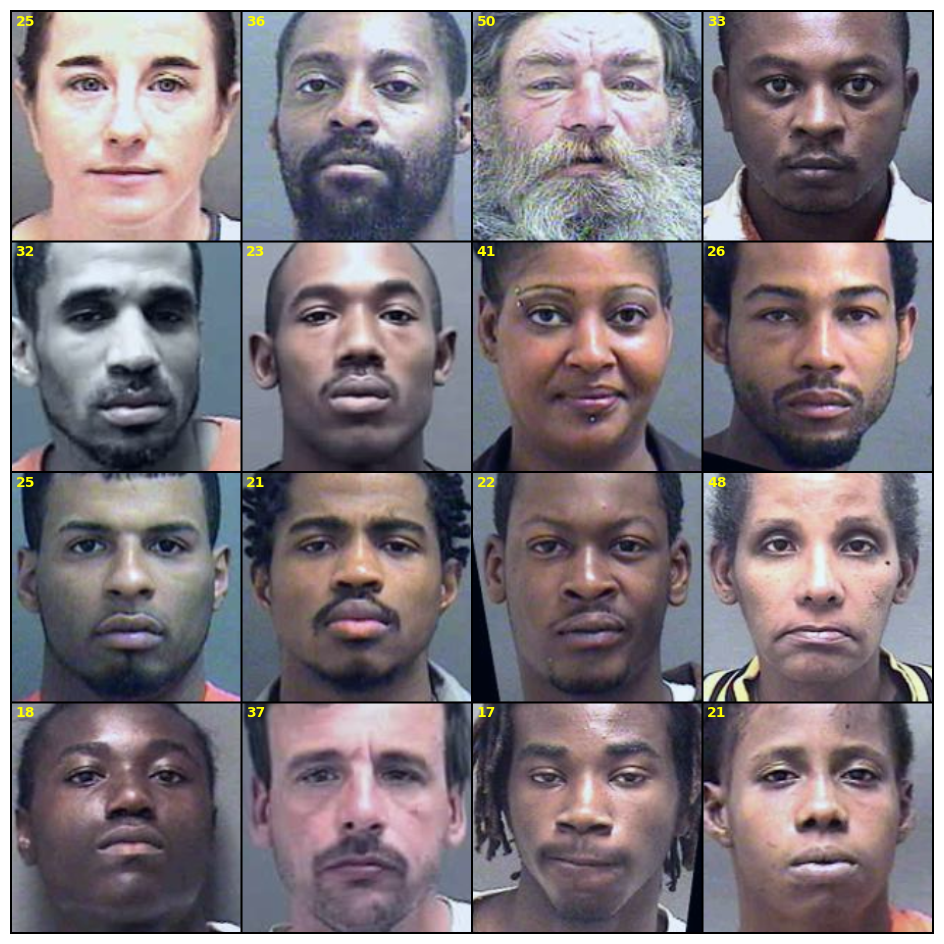

In [56]:
# Sélectionner quelques indices (par ex. 16 images aléatoires)
import random
sample_idx = random.sample(range(len(predictions)), 16)

# Charger les images correspondantes depuis le dataset de test
images = [test_loader.dataset[i][0] for i in sample_idx]  # [0] = image
ages   = [predictions[i] for i in sample_idx]             # prédictions

# Empiler en batch
images_tensor = torch.stack(images)

# Créer une grille
grid = vutils.make_grid(images_tensor, nrow=4, normalize=True, scale_each=True)
npimg = grid.numpy().transpose((1, 2, 0))

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(npimg)
ax.axis("off")

nrow = 4
for i, age in enumerate(ages):
    row, col = divmod(i, nrow)
    ax.text(col * (images_tensor.size(3)+2) + 5,
            row * (images_tensor.size(2)+2) + 15,
            f"{float(age):.0f}", color="yellow", fontsize=10, weight="bold")

plt.show()



In [57]:
# Créer le CSV
import pandas as pd
df = pd.DataFrame({'ID': image_ids, 'Age': [int(pred[0]) for pred in predictions]})  # Convertir en int
df.to_csv('task2_predictions.csv', index=False)
print("Fichier predictions.csv généré avec succès !")

Fichier predictions.csv généré avec succès !


In [58]:
df

,ID,Age
0,45,33
1,56,16
2,89,22
3,20,27
4,58,42
...,...,...
195,134,23
196,136,34
197,90,33
198,25,19
